# Connecting attention and linear layers in a transformer block

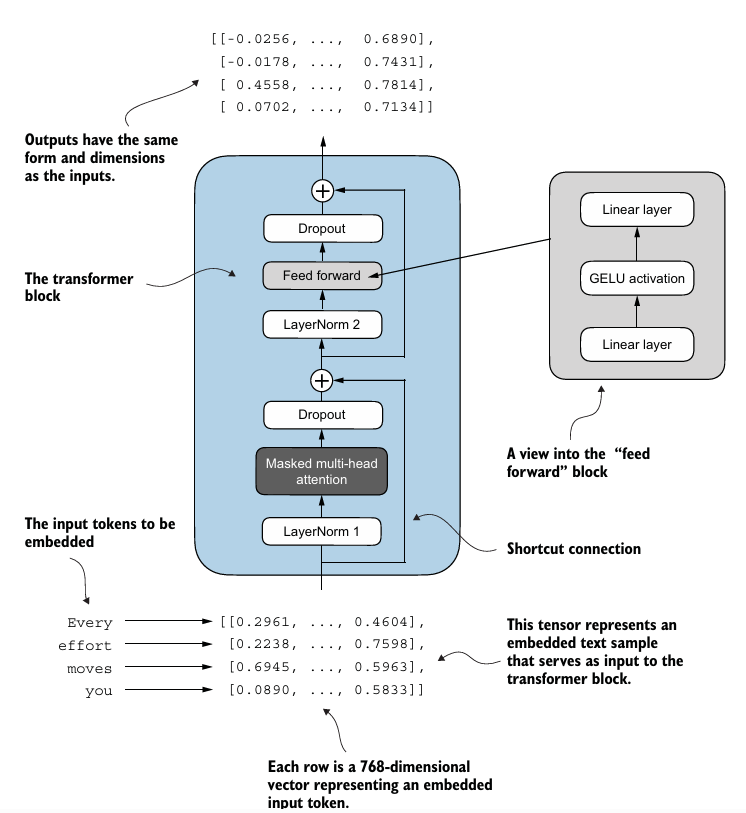

In [1]:
import torch
import torch.nn as nn

In [2]:
MODEL_CONFIG_124M = {
    "vocab_size": 50257,     
    "context_length": 1024,  
    "emb_dim": 768,          
    "n_heads": 12,           
    "n_layers": 12,          
    "drop_rate": 0.1,        
    "qkv_bias": False   
}

In [3]:
from components import *

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attn = MultiHeadAttention(
            d_in = config["emb_dim"],
            d_out = config["emb_dim"],
            context_length = config["context_length"],
            num_heads = config["n_heads"],
            dropout = config["drop_rate"],
            qkv_bias = config["qkv_bias"])
        self.feedforward = FeedForward(config)
        self.attnnorm = LayerNorm(config["emb_dim"])
        self.ffnorm = LayerNorm(config["emb_dim"])
        self.drop_shortcut = nn.Dropout(config["drop_rate"])
    
    def forward(self, input):

        shortcut = input
        input = self.attnnorm(input)
        input = self.attn(input)
        input = self.drop_shortcut(input)
        input = input + shortcut

        shortcut = input
        input = self.ffnorm(input)
        input = self.feedforward(input)
        input = self.drop_shortcut(input)
        input = input + shortcut
        return input

In [6]:
torch.manual_seed(123)

input = torch.rand(2,4,768)
tfb = TransformerBlock(MODEL_CONFIG_124M)
output = tfb(input)

In [7]:
output.shape

torch.Size([2, 4, 768])